### **Geo-Energy Engineering Application Final Project (Q3, 2026)**

### Project II/II (50% Total Weight)

**Description:**

Use realizations #31 and #72 from the full Egg model at
https://data.4tu.nl/articles/_/12707642/1. We focus on 2D reservoir models extracted from this 3D box
model and assume Δ𝑥 = Δ𝑦 = 30 [𝑚]. You can write a brief script to read the values, and assign it to Kx
and Ky for each cell (i, j, k).


**Tasks:**

1. Make a code that reads permeability for the middle layer of Egg model and plot it for two realizations. The x-y plane should have 60 x 60 cells. [10%]

2. For realization #31, insert an injection well at cell (1,1) with fixed BHP at 200 bars and a production well at (60, 60) with fixed BHP at 100 bars. Assume the radius of both wells Rw = 0.2. The initial pressure is 150 bars. Plot the pressure distribution after 10 days of simulation. [10%]

3. For realization #72, plot the pressure for 2 wells at (60,1) (injector) and (1,60) (producer) with the same pressure values as item 2 above. [10%]

4. Simulate the injection of CO2 in the aquifer for 1 year in both realizations using the same injection conditions and plot the migration of the injected plume. You can use any of your codes for it but clearly specify your assumptions. Place the injection well in the center and use the Kr curves according to your best knowledge, based on the multiphase flow lectures and practical activities. Justify your choices of parameters. [70%]

In [3]:
import numpy as numpy
import matplotlib.pyplot as plt


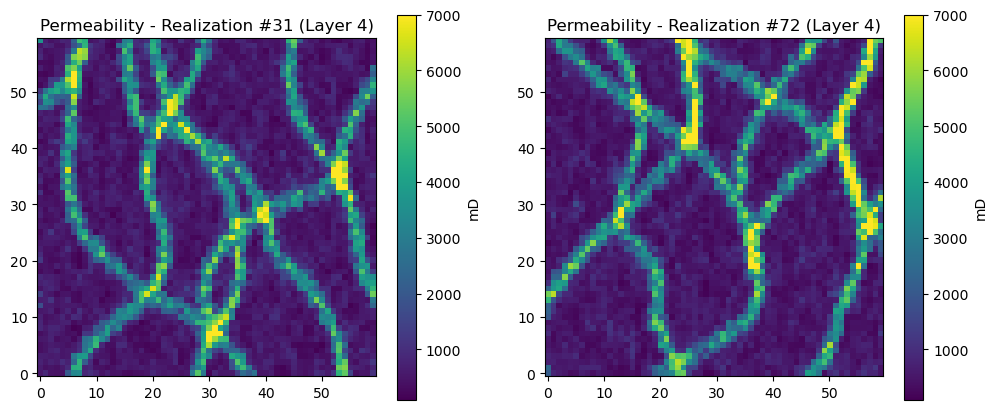

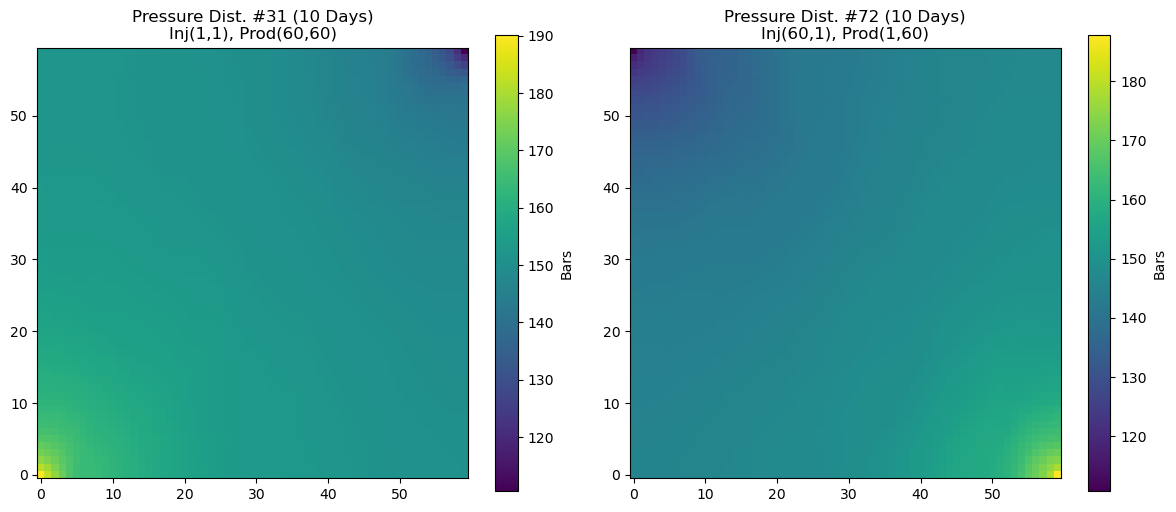

In [ ]:
import zipfile, re, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# --------- Constants & Functions from Provided Code ---------
c_unit = 0.008526
mu = 1.0
rho0 = 1.0
cf = 1e-4
phi0 = 0.3
cr = 1e-5
p_ref = 100.0

def rho(p_i): return rho0 * (1.0 + cf * (p_i - p_ref))
def phi(p_i): return phi0 * (1.0 + cr * (p_i - p_ref))

def k_harm(a, b): return 2.0 * a * b / (a + b)

def gid(i, j, nx): return i + nx * j

def Gamma_well(perm, dz, dx, rw=0.2):
    r0 = 0.208 * dx
    return c_unit * (2.0 * np.pi * perm * dz) / (np.log(r0 / rw))

def read_block(text, keyword):
    m = re.search(rf"{keyword}\s*(.*?)\s*/", text, flags=re.S | re.I)
    if not m: return None
    return np.fromstring(m.group(1).replace("\r"," ").replace("\n"," "), sep=" ")

# --------- Task 1: Load Realizations & Plot Permeability ---------
egg_zip_path = "data.zip" 
nx, ny, nz = 60, 60, 7
dx = dy = 30.0
dz = 10.0 
mid_layer = 3 # Middle layer of 7 (0-indexed)

realizations = [31, 72]
k_data = {}

with zipfile.ZipFile(egg_zip_path, "r") as z:
    for rid in realizations:
        # Find the specific realization file
        cand = [name for name in z.namelist() if re.search(rf"PERM{rid}_ECL\.INC$", name)]
        if not cand: raise FileNotFoundError(f"PERM{rid} not found.")
        
        txt = z.read(cand[0]).decode("utf-8", errors="ignore")
        # Read PERMX and reshape to (NZ, NY, NX)
        pk = read_block(txt, "PERMX").reshape((nz, ny, nx))
        # Extract middle layer (i, j, k) -> we take k=3
        k_data[rid] = pk[mid_layer, :, :]

# Plotting Task 1
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for i, rid in enumerate(realizations):
    im = axs[i].imshow(k_data[rid], origin="lower", cmap='viridis')
    axs[i].set_title(f"Permeability - Realization #{rid} (Layer 4)")
    fig.colorbar(im, ax=axs[i], label='mD')
plt.show()

# --------- Simulation Engine ---------
def run_simulation(kx2D, ky2D, inj_pos, prod_pos, p_init=150.0, p_well_inj=200.0, p_well_prod=100.0):
    nb = nx * ny
    V = dx * dy * dz
    dt = 1.0 # 1 day
    target_time = 10 # days
    steps = int(target_time / dt)
    
    kxv = kx2D.flatten()
    kyv = ky2D.flatten()
    
    # Build Connection List
    bm, bp, Tc = [], [], []
    Tx = c_unit * (1.0/mu) * (dz * dy) / dx
    Ty = c_unit * (1.0/mu) * (dz * dx) / dy

    for j in range(ny):
        for i in range(nx - 1):
            m, p_idx = gid(i, j, nx), gid(i + 1, j, nx)
            bm.append(m); bp.append(p_idx)
            Tc.append(Tx * k_harm(kxv[m], kxv[p_idx]))
    for j in range(ny - 1):
        for i in range(nx):
            m, p_idx = gid(i, j, nx), gid(i, j + 1, nx)
            bm.append(m); bp.append(p_idx)
            Tc.append(Ty * k_harm(kyv[m], kyv[p_idx]))
            
    p = np.ones(nb) * p_init
    
    for _ in range(steps):
        A = lil_matrix((nb, nb))
        b = np.zeros(nb)
        # Accumulation
        for i in range(nb):
            Ci = (rho0 * phi(p[i]) * cf + phi0 * rho(p[i]) * cr) * V / dt
            A[i,i] += Ci
            b[i] += Ci * p[i]
        # Transmissibility
        for kconn in range(len(bm)):
            m, p_idx, Tk_base = bm[kconn], bp[kconn], Tc[kconn]
            Tk = Tk_base * (rho(p[m]) + rho(p[p_idx])) / 2
            A[m,m] += Tk; A[m,p_idx] -= Tk
            A[p_idx,p_idx] += Tk; A[p_idx,m] -= Tk
            
        # Wells
        # Injector
        idx_inj = gid(inj_pos[0]-1, inj_pos[1]-1, nx)
        Tw_inj = Gamma_well(kxv[idx_inj], dz, dx) * rho(p[idx_inj])
        A[idx_inj, idx_inj] += Tw_inj
        b[idx_inj] += Tw_inj * p_well_inj
        
        # Producer
        idx_prod = gid(prod_pos[0]-1, prod_pos[1]-1, nx)
        Tw_prod = Gamma_well(kxv[idx_prod], dz, dx) * rho(p[idx_prod])
        A[idx_prod, idx_prod] += Tw_prod
        b[idx_prod] += Tw_prod * p_well_prod
        
        p = spsolve(A.tocsr(), b)
    
    return p.reshape((ny, nx))


# Wells: Inj(1,1), Prod(60,60)
p_map_31 = run_simulation(k_data[31], k_data[31], (1,1), (60,60))


p_map_72 = run_simulation(k_data[72], k_data[72], (60,1), (1,60))

# Final Plotting for 2 & 3
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
im1 = axs[0].imshow(p_map_31, origin="lower")
axs[0].set_title("Pressure Dist. #31 (10 Days)\nInj(1,1), Prod(60,60)")
fig.colorbar(im1, ax=axs[0], label='Bars')

im2 = axs[1].imshow(p_map_72, origin="lower")
axs[1].set_title("Pressure Dist. #72 (10 Days)\nInj(60,1), Prod(1,60)")
fig.colorbar(im2, ax=axs[1], label='Bars')

plt.tight_layout()
plt.show()

Simulating 365 days for Realization #31...
Simulating 365 days for Realization #72...


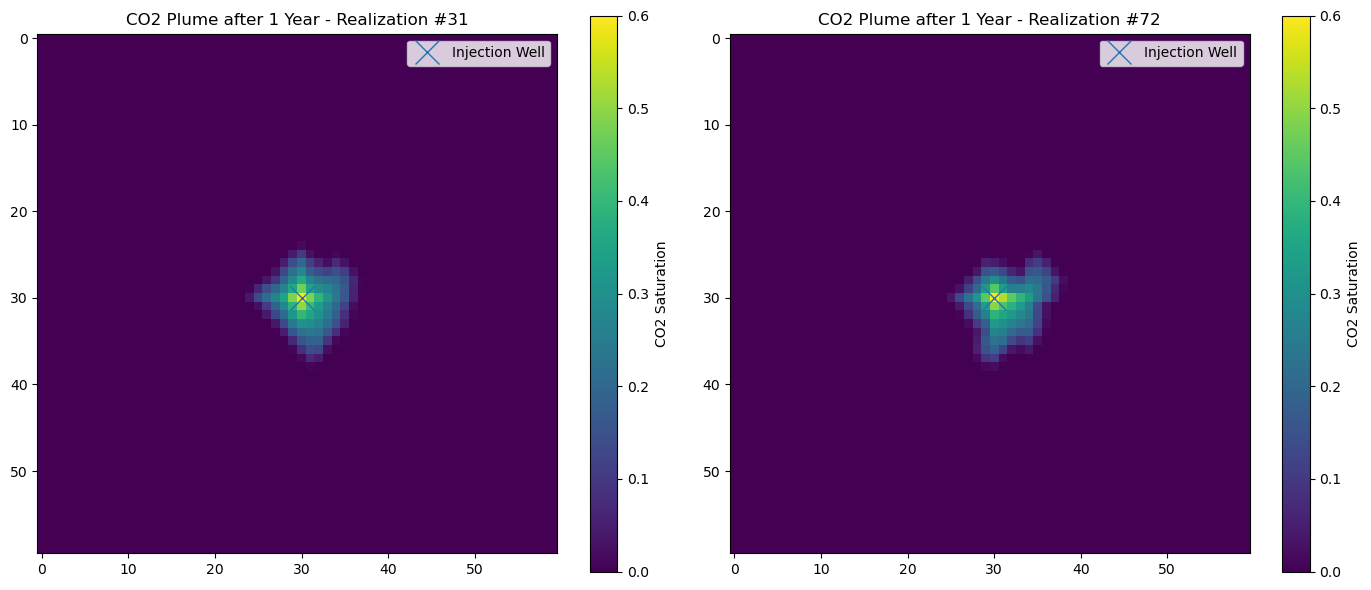

In [ ]:
nx, ny = 60, 60
dx = dy = 30.0         
h = 10.0               
phi = 0.2              
mu_w = 1.0 * 1e-3      
mu_g = 0.05 * 1e-3     


Swi = 0.2
Sgr = 0.0
krw0 = 1.0
krg0 = 0.8
nw = 2.0
ng = 2.0


days = 365
dt_days = 0.5          
n_steps = int(days / dt_days)
dt_sec = dt_days * 86400


Q_inj = 100.0 / 86400  


def calc_kr(Sg):
    
    Sw = 1.0 - Sg
 
    Sw_norm = np.clip((Sw - Swi) / (1.0 - Swi - Sgr), 0.0, 1.0)
    Sg_norm = np.clip((Sg - Sgr) / (1.0 - Swi - Sgr), 0.0, 1.0)
    
    krw = krw0 * (Sw_norm ** nw)
    krg = krg0 * (Sg_norm ** ng)
    return krw, krg

def read_middle_layer(filename):
    
    values = []
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('PERM') or line.startswith('--'):
                continue
            for item in line.split():
                try:
                    values.append(float(item))
                except ValueError:
                    pass
    perm_1d = np.array(values)
    nz = len(perm_1d) // (nx * ny)
    return perm_1d.reshape((nz, ny, nx))[nz // 2, :, :]


def run_impes(k_file, title):
    K_mD = read_middle_layer(k_file)
    K = K_mD * 1e-15  
    
    N = nx * ny
    Vp = dx * dy * h * phi

    P = np.ones(N) * 150e5  
    Sg = np.zeros(N)       
    
   
    idx_inj = 30 * nx + 30  
    
 
    producers = [
        (0, 0), (nx-1, 0), (0, ny-1), (nx-1, ny-1)
    ]
    prod_indices = [j*nx + i for i, j in producers]
    P_prod = 150e5
    
    print(f"Simulating {days} days for {title}...")
    
    for step in range(n_steps):
        
        krw, krg = calc_kr(Sg)
        lam_w = krw / mu_w
        lam_g = krg / mu_g
        lam_t = lam_w + lam_g
        
        
        row, col, data = [], [], []
        b = np.zeros(N)
        
        
        b[idx_inj] = Q_inj
        
     
        for p_idx in prod_indices:
            WI = (2 * np.pi * K[p_idx // nx, p_idx % nx] * h) / np.log((0.2 * dx) / 0.2)
            b[p_idx] += (WI * lam_t[p_idx]) * P_prod
        
        
        for j in range(ny):
            for i in range(nx):
                idx = j * nx + i
                diag_val = 0.0
                
                if idx in prod_indices:
                    WI = (2 * np.pi * K[j, i] * h) / np.log((0.2 * dx) / 0.2)
                    diag_val += WI * lam_t[idx]
                
                
                if i > 0:
                    idx_w = idx - 1
                    K_harm = 2 * K[j, i] * K[j, i-1] / (K[j, i] + K[j, i-1])
                    L_avg = (lam_t[idx] + lam_t[idx_w]) / 2.0
                    T = (K_harm * dy * h / dx) * L_avg
                    diag_val += T
                    row.append(idx); col.append(idx_w); data.append(-T)
                
                
                if i < nx - 1:
                    idx_e = idx + 1
                    K_harm = 2 * K[j, i] * K[j, i+1] / (K[j, i] + K[j, i+1])
                    L_avg = (lam_t[idx] + lam_t[idx_e]) / 2.0
                    T = (K_harm * dy * h / dx) * L_avg
                    diag_val += T
                    row.append(idx); col.append(idx_e); data.append(-T)
                
                
                if j > 0:
                    idx_n = idx - nx
                    K_harm = 2 * K[j, i] * K[j-1, i] / (K[j, i] + K[j-1, i])
                    L_avg = (lam_t[idx] + lam_t[idx_n]) / 2.0
                    T = (K_harm * dx * h / dy) * L_avg
                    diag_val += T
                    row.append(idx); col.append(idx_n); data.append(-T)
                
                
                if j < ny - 1:
                    idx_s = idx + nx
                    K_harm = 2 * K[j, i] * K[j+1, i] / (K[j, i] + K[j+1, i])
                    L_avg = (lam_t[idx] + lam_t[idx_s]) / 2.0
                    T = (K_harm * dx * h / dy) * L_avg
                    diag_val += T
                    row.append(idx); col.append(idx_s); data.append(-T)
                
                row.append(idx); col.append(idx); data.append(diag_val)
                
        A = csr_matrix((data, (row, col)), shape=(N, N))
        
       
        P = spsolve(A, b)
        
 
        Sg_new = Sg.copy()
        Sg_new[idx_inj] += (Q_inj * dt_sec) / Vp  
        

        for j in range(ny):
            for i in range(nx):
                idx = j * nx + i
                
                
                if i > 0:
                    idx_w = idx - 1
                    K_harm = 2 * K[j, i] * K[j, i-1] / (K[j, i] + K[j, i-1])
                    dP = P[idx_w] - P[idx]
                    T = (K_harm * dy * h / dx)
                    L_avg = (lam_t[idx] + lam_t[idx_w]) / 2.0
                    q_t = T * L_avg * abs(dP)
                    
                    if dP > 0: 
                        f_g = lam_g[idx_w] / lam_t[idx_w]
                        Sg_new[idx] += (q_t * f_g * dt_sec) / Vp
                        Sg_new[idx_w] -= (q_t * f_g * dt_sec) / Vp
                    elif dP < 0: 
                        f_g = lam_g[idx] / lam_t[idx]
                        Sg_new[idx_w] += (q_t * f_g * dt_sec) / Vp
                        Sg_new[idx] -= (q_t * f_g * dt_sec) / Vp

                
                if j > 0:
                    idx_n = idx - nx
                    K_harm = 2 * K[j, i] * K[j-1, i] / (K[j, i] + K[j-1, i])
                    dP = P[idx_n] - P[idx]
                    T = (K_harm * dx * h / dy)
                    L_avg = (lam_t[idx] + lam_t[idx_n]) / 2.0
                    q_t = T * L_avg * abs(dP)
                    
                    if dP > 0: 
                        f_g = lam_g[idx_n] / lam_t[idx_n]
                        Sg_new[idx] += (q_t * f_g * dt_sec) / Vp
                        Sg_new[idx_n] -= (q_t * f_g * dt_sec) / Vp
                    elif dP < 0: 
                        f_g = lam_g[idx] / lam_t[idx]
                        Sg_new[idx_n] += (q_t * f_g * dt_sec) / Vp
                        Sg_new[idx] -= (q_t * f_g * dt_sec) / Vp
                        
        Sg = np.clip(Sg_new, 0.0, 1.0 - Swi)
        
    return Sg.reshape((ny, nx))


if __name__ == "__main__":
    Sg_31 = run_impes('PERM31_ECL.INC', 'Realization #31')
    Sg_72 = run_impes('PERM72_ECL.INC', 'Realization #72')
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    

    im1 = axes[0].imshow(Sg_31, cmap='viridis', origin='upper', vmin=0.0, vmax=0.6)
    axes[0].set_title('CO2 Plume after 1 Year - Realization #31')
    axes[0].plot(30, 30, 'x', markersize=17, label='Injection Well')
    axes[0].legend()
    fig.colorbar(im1, ax=axes[0], label='CO2 Saturation')
    

    im2 = axes[1].imshow(Sg_72, cmap='viridis', origin='upper', vmin=0.0, vmax=0.6)
    axes[1].set_title('CO2 Plume after 1 Year - Realization #72')
    axes[1].plot(30, 30, 'x', markersize=17, label='Injection Well')
    axes[1].legend()
    fig.colorbar(im2, ax=axes[1], label='CO2 Saturation')
    
    plt.tight_layout()
    plt.show()